In [18]:
from pathlib import Path

patch_root_candidates = [
    Path('output/icaird_cervical_mini/pipeline_research/patches'),
    Path('../output/icaird_cervical_mini/pipeline_research/patches'),
]

patches = next((path for path in patch_root_candidates if path.exists()), patch_root_candidates[0])
print(f'Using patch directory: {patches.resolve()}')
print(f'Patches exists: {patches.exists()}')


Using patch directory: /Users/dm236/Documents/repos/histokit/output/icaird_cervical_mini/pipeline_research/patches
Patches exists: True


In [21]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image

def show_patch_grid(base_dir, patch_types, n=16, seed=42, figsize=(8, 8)):
    """Display up to n PNG patches sampled across the requested class folders."""
    base_dir = Path(base_dir)
    if isinstance(patch_types, str):
        patch_types = [patch_types]
    else:
        patch_types = list(dict.fromkeys(patch_types))
    if n < 1:
        raise ValueError('n must be at least 1')
    if not patch_types:
        raise ValueError('patch_types must contain at least one class label')

    available_files = {}
    for patch_type in patch_types:
        patch_dir = base_dir / patch_type
        if not patch_dir.exists():
            raise FileNotFoundError(f'Patch directory does not exist: {patch_dir.resolve()}')
        png_files = sorted(patch_dir.glob('*.png'))
        if not png_files:
            raise FileNotFoundError(f'No PNG files found in {patch_dir.resolve()}')
        available_files[patch_type] = png_files

    rng = random.Random(seed)
    remaining_files = {
        patch_type: rng.sample(files, k=len(files))
        for patch_type, files in available_files.items()
    }
    selected_items = []

    while len(selected_items) < n:
        available_classes = [
            patch_type
            for patch_type, files in remaining_files.items()
            if files
        ]
        if not available_classes:
            break
        rng.shuffle(available_classes)
        for patch_type in available_classes:
            if len(selected_items) >= n:
                break
            selected_items.append((patch_type, remaining_files[patch_type].pop()))

    rng.shuffle(selected_items)
    count = len(selected_items)
    grid_cols = math.ceil(count ** 0.5)
    grid_rows = math.ceil(count / grid_cols)
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=figsize, squeeze=False)
    for ax, (patch_type, image_path) in zip(axes.flat, selected_items):
        with Image.open(image_path) as img:
            ax.imshow(img)
        ax.set_title(patch_type.replace('_', ' ').title(), fontsize=14)
        ax.axis('off')
    for ax in list(axes.flat)[count:]:
        ax.axis('off')
    fig.tight_layout()
    display(fig)
    plt.close(fig)


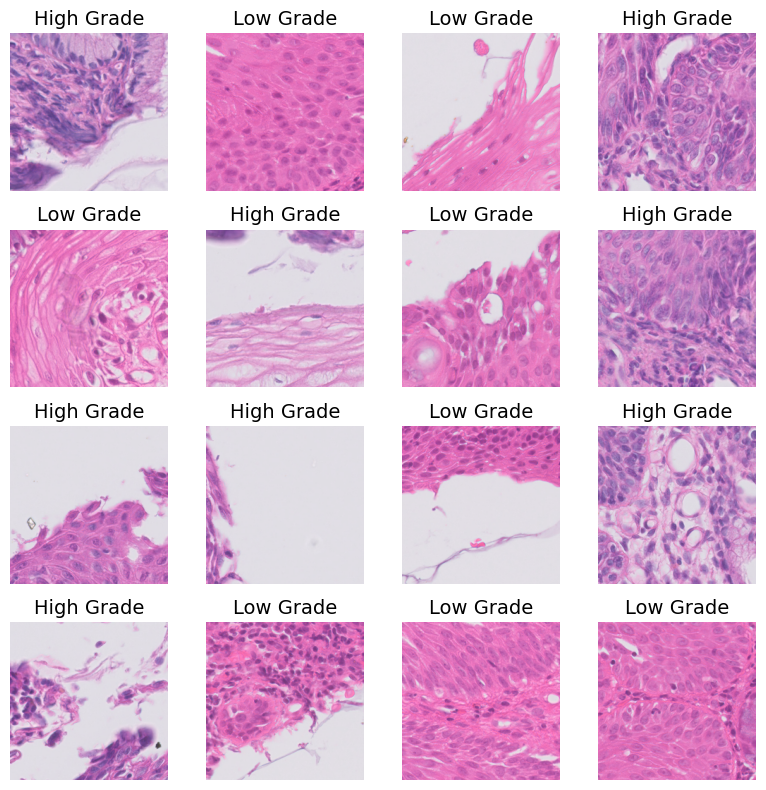

In [22]:
show_patch_grid(patches, ['high_grade', 'low_grade'], n=16)
